DBSCAN Cluster Counts:
DBSCAN_Cluster
 1    331
 2    331
 0    330
-1     25
 3      2
Name: count, dtype: int64


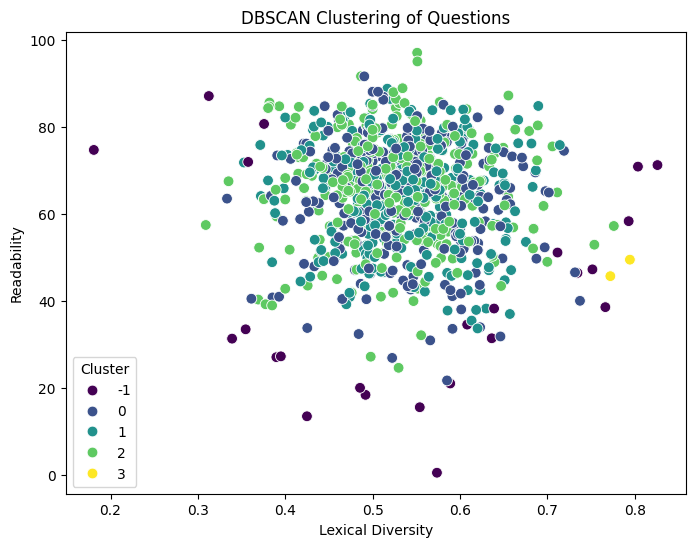

✅ DBSCAN clusters added and dataset saved.


In [2]:
# ===============================
# 1️⃣ Import Libraries
# ===============================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 2️⃣ Load Dataset
# ===============================
df = pd.read_excel("ALL_with_features.xlsx")

# ===============================
# 3️⃣ Fill missing numerical values with column mean
# ===============================
num_cols = ['Lexical Diversity', 'Avg Sentence Length', 'Readability', 'DoK_Level']
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

# ===============================
# 4️⃣ Feature Selection
# ===============================
features = num_cols
X = df[features].values

# ===============================
# 5️⃣ Scale Features
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# 6️⃣ Train DBSCAN
# ===============================
dbscan = DBSCAN(eps=1.2, min_samples=5)  # tune eps as needed
dbscan.fit(X_scaled)

# Add cluster labels to dataset
df['DBSCAN_Cluster'] = dbscan.labels_

# ===============================
# 7️⃣ Inspect / Evaluate
# ===============================
print("DBSCAN Cluster Counts:")
print(df['DBSCAN_Cluster'].value_counts())

# ===============================
# 8️⃣ Visualize Clusters
# ===============================
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Lexical Diversity'],
    y=df['Readability'],
    hue=df['DBSCAN_Cluster'],
    palette='viridis',
    s=60
)
plt.title("DBSCAN Clustering of Questions")
plt.xlabel("Lexical Diversity")
plt.ylabel("Readability")
plt.legend(title="Cluster")
plt.show()

# ===============================
# 9️⃣ Save Updated Dataset
# ===============================
df.to_excel("ALL_with_features.xlsx", index=False)
print("✅ DBSCAN clusters added and dataset saved.")

Silhouette Score: 0.16893785969401823

Cluster Distribution:
Spectral_Cluster
1    345
0    339
2    335
Name: count, dtype: int64


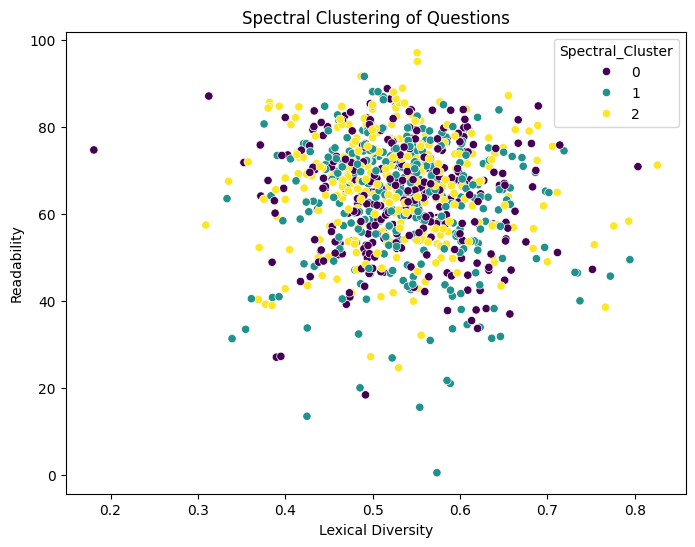

Spectral clustering labels saved.


In [3]:
# ==============================
# 1 Import Libraries
# ==============================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 2 Load Dataset
# ==============================
df = pd.read_excel("ALL_with_features.xlsx")

# ==============================
# 3 Handle Missing Values
# ==============================
cols = ['Lexical Diversity','Avg Sentence Length','Readability','DoK_Level']

for c in cols:
    df[c] = df[c].fillna(df[c].mean())

# ==============================
# 4 Feature Selection
# ==============================
X = df[cols]

# ==============================
# 5 Feature Scaling
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 6 Build and Train Model
# ==============================
spectral = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)

labels = spectral.fit_predict(X_scaled)

df["Spectral_Cluster"] = labels

# ==============================
# 7 Evaluate Model
# ==============================
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

print("\nCluster Distribution:")
print(df["Spectral_Cluster"].value_counts())

# ==============================
# 8 Visualization
# ==============================
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Lexical Diversity'],
    y=df['Readability'],
    hue=df['Spectral_Cluster'],
    palette='viridis'
)

plt.title("Spectral Clustering of Questions")
plt.show()

# ==============================
# 9 Save Results
# ==============================
df.to_excel("ALL_with_features.xlsx", index=False)

print("Spectral clustering labels saved.")

In [4]:
from sklearn.cluster import DBSCAN, SpectralClustering
import joblib

# ==============================
# DBSCAN MODEL
# ==============================

# Create DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)

# Train model
# dbscan.fit(X_scaled)

# Save DBSCAN model
joblib.dump(dbscan, "dbscan_model.pkl")

# Load DBSCAN model later
dbscan_loaded = joblib.load("dbscan_model.pkl")


# ==============================
# SPECTRAL CLUSTERING MODEL
# ==============================

# Create Spectral Clustering model
spectral_model = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42
)

# Train model
# spectral_model.fit(X_scaled)

# Save Spectral model
joblib.dump(spectral_model, "spectral_model.pkl")

# Load Spectral model later
spectral_loaded = joblib.load("spectral_model.pkl")